#  الاطارات:

## الهدف:

* فهم ما هي الاطارات

* تعلم ايجاد ورسم الاطارات الخ

- سنرى هذه التوابع:

`cv2.findContours`, `cv2.drawContours`

## ما هي الاطارات؟

يمكن اعتبار الاطارات كمنحنيات تجمع كل النقاط المتصلة , التي لديها نفس الشدة او اللون , وهذه الاطارات هي ادوات مفيدة لتحليل الاشكال واكتشاف او التعرف على الاجسام 
ولذلك راعي التالي:

- اولا - من اجل نتائج افضل استخدم الصور الثنائية و لهذا استخدم التعتيب , او مكتشف الحواف كاني

- ثانيا - تابع ايجاد الحواف يحور الصورة الاصل . لذلك اذا اردت الحفاظ على الصور بامكانك استخدام نسخة احتياطية لها

- ثالثا - ايجاد الاطارات في 
**OpenCV**
يماثل ايجاد الاجسام البيضاء من الخلفية السوداء لذلك على الخلفية ان تكون سوداء و الجسم ان يكون ابيض 


والتالي مثال:

In [1]:
import numpy as np
import cv2

im = cv2.imread('box.png')
imgray = cv2.cvtColor(im,cv2.COLOR_BGR2GRAY)
ret,thresh = cv2.threshold(imgray,120,255,0)
contours, hierarchy = cv2.findContours(
    thresh,cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)

لذلك هناك 3 متغيرات للتابع السابق `findContours`, اولها صورة الدخل
`thresh`
, والثاني حالة استرداد الاطار
`cv2.RETR_TREE`
والثالث طريقة تقريب الاطار .
`cv2.CHAIN_APPROX_SIMPLE`
والخرج هو الصورة الثنائية وسلسلة الاطارات المرتبة المكتشفة كقائمة بايثون
**List**
 حيث كل اطار مفرد هو مصفوفة 
**Numpy**
من الاحداثيات لنقاط الحدود للجسم 


** ملاحظة** 

سنناقش المتغيرات الثالثة والرابعة لاحقاً 


## كيف سترسم الاطارات: 
لنرسم الاطارات علينا استخدام التابع 
<p style="text-align:center;font-size:1.4em;">
    <strong>cv2.drawContours</strong>
</p>

ويمكن نظريا استخدامه لرسم اي شكل لدينا نقاطه المحيطية ,دخله الاول هو صورة الاصل الدخل الثاني هو الاطارات المطلوب رسمها والتي تمرر كقائمة بايثون والدخل الثالث ترتيب الاطار المرغوب رسمه وفقي حالة اردنا رسمها كلها نمرر `-1` وبقية المداخل هي السماكة واللون . الخ
 
 ولرسم كل الاطارات بالصورة نكتب

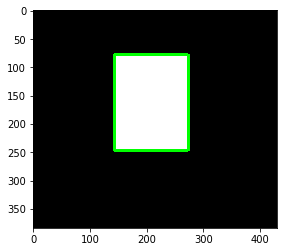

In [3]:
from matplotlib import pyplot as plt
%matplotlib inline

cv2.drawContours(im, contours, -1, (0,255,0), 3)
plt.imshow(im)

ولرسم اطار مفرد نمرر ترتيبه , هنا اطار واحد , ولذلك نأخذه ..

In [6]:
cv2.drawContours(im, contours, 0, (0,255,0), 3)

ولكن معظم الوقت الطريقة ادناه مفيدة 
, وحيث قد تلاحظ ان لها نفس الاثر , سنرى قريبا انها اكثر فائدة



In [7]:
cnt = contours[0]
img = cv2.drawContours(im, [cnt], 0, (0,255,0), 3)

## طرق تقريب الاطارات:
وهذا هو المتغير الثالث في التابع , 
<p style="text-align:center;font-size:1.4em;">
<strong> cv2.findControus </strong>
    </p>

اعلاه قلنا ان الاطارات هي حدود الشكل مع نفس الشدة , ولقد خزنّا احداثيات نقاطها , ولكن ما الدقة التي ستخزن خلالها , هذا ما يتم تحديده وفق طريقة التقريب
,
فاذا مررنا 
`cv2.CHAIN_APPROX_NONE `
سيتم تخزين كل النقاط للحدود , ولكن هل نحتاجها؟ , مثلاً لخط مستقيم هل نحتاج كل نقاطه , بل تكفي نقطتا البداية والتهاية , 
وهذا ما تفعله
` cv2.CHAIN_APPROX_SIMPLE`
فهي تزيل كل النقاط الفائضة , وتوفر بذلك من حجم الذاكرة 
,
 والتالي يعطي الاطار بالحالة الاولى: 

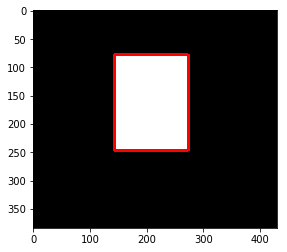

[array([[[143,  78]],

       [[143,  79]],

       [[143,  80]],

       ..., 
       [[146,  78]],

       [[145,  78]],

       [[144,  78]]])]


In [10]:
img = cv2.imread('box.png')
im = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
ret,thresh = cv2.threshold(im,127,255,cv2.THRESH_BINARY)
contours, hierarchy = cv2.findContours(
    thresh,cv2.RETR_TREE,cv2.CHAIN_APPROX_NONE)
cv2.drawContours(img, contours, -1, (255,0,0), 3)

plt.imshow(img, cmap = 'gray')
plt.show()

print(contours)

وهنا الحالة الثانية , فقط الزوايا

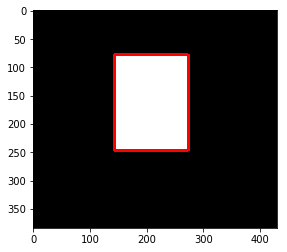

[array([[[143,  78]],

       [[143, 247]],

       [[273, 247]],

       [[273,  78]]])]


In [11]:
img = cv2.imread('box.png')
im = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
ret,thresh = cv2.threshold(im,127,255,cv2.THRESH_BINARY)
contours, hierarchy = cv2.findContours(
    thresh,cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)
cv2.drawContours(img, contours, -1, (255,0,0), 3)

plt.imshow(img, cmap = 'gray')
plt.show()

print contours

وعلى كل الاحوال نتيجة الرسم واحدة , لأن التابع يرسم بكلا الحالتين

# خصائص الاطارات:
*وهنا سنتعلم*

- : ايجاد الخصائص المختلفة للاطارات مثل:
**المساحة , الابعاد والصندوق المحيط**

- وسنرى العديد من التوابع المرتبطة بالاطارات


## العزوم
عزوم الصورة تساعدك على حساب بعض الخصائص مثل مركز الكتلة للجسم مساحة الجسم ,
وذلك للصورة الثنائية 
مثلاً التابع:
<p style="text-align:center;font-size:1.4em;">
<strong>cv2.moments</strong>
</p>
يعطي قاموساً `dict` لكل قيم العزوم المحسوبة   ,
شاهد المثال التالي


In [12]:
import cv2
import numpy as np

img = cv2.imread('box.png',0)
ret,thresh = cv2.threshold(img,127,255,0)
contours,hierarchy = cv2.findContours(thresh, 1, 2)
cnt = contours[0]
M = cv2.moments(cnt)

print len(M)#what length of info
print '=========Whats info============'
print M

24
=========Whats info============
{'mu02': 52290430.833333254, 'mu03': 4.57763671875e-05, 'm11': 742586000.0, 'nu02': 0.10833333333333317, 'm12': 131546634613.33333, 'mu21': 2.86102294921875e-06, 'mu20': 30941083.333333254, 'nu20': 0.06410256410256394, 'm30': 217013332640.0, 'nu21': 3.9989520724987846e-17, 'mu11': 0.0, 'mu12': 1.1444091796875e-05, 'nu11': 0.0, 'nu12': 1.5995808289995138e-16, 'm02': 632435743.3333333, 'm03': 119765198312.5, 'm00': 21970.0, 'm01': 3570125.0, 'mu30': 6.103515625e-05, 'nu30': 8.531097754664074e-16, 'nu03': 6.398323315998055e-16, 'm10': 4569760.0, 'm20': 981451163.3333333, 'm21': 159485814041.66666}


 ومن هذه القيم يمكن اشتقاق قيم مفيدة 
 ,
 مثل **المركز او المساحة**, الاول تحديداً , يحسب كالاتي

In [13]:
cx = int(M['m10']/M['m00'])
cy = int(M['m01']/M['m00'])

print cx,cy

208 162


## مساحة الاطار:
تعطى مساحة الاطار بالتابع , 
<p style="text-align:center;font-size:1.4em;">
<strong> cv2.contourArea </strong>
</p>
أو:
** M['m00'] **


In [14]:
area = cv2.contourArea(cnt)
print area

21970.0


## محيط الاطار:
ويدعى ايضا طول القطر 
, ويتم ايجاده عبر التابع
<p style="text-align:center;font-size:1.4em;">
<strong> cv2.arcLength </strong>
</p>

ومتغيره الثاني يحدد ما اذا كان الشكل هو اطارا مغلقاً ,`True`, ام فقط منحني`False` , كالتالي

In [15]:
perimeter = cv2.arcLength(cnt,True)
print perimeter

598.0


## تقريب الاطار: 
سيقرب شكل الاطار لشكل اخر مع عدد اقل من الرؤوس بالاعتماد على الدقة التي نحددها , وهذا يطبق وفق خوارزمية محددة 

مثلا افترض انك تبحث عن مربع في صورة , ولكن بسبب مشكلة ما حصلت على مربع مشوه ,

لذلك يمكننا استخدام هذا التابع للحصول على المربع المطلوب ومتغيره الثاني هو قيمة الخطأ الاعظمي المسموح والذي يجب اختياره بعناية للحصول على النتيجة المرغوبة

[[[143  78]]

 [[143 247]]

 [[273 247]]

 [[273  78]]]
[[[143  78]]

 [[143 247]]

 [[273 247]]

 [[273  78]]]


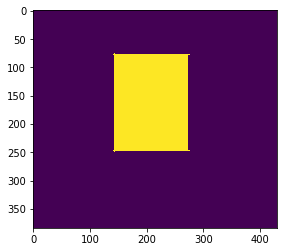

In [24]:
epsilon = 0.01*cv2.arcLength(cnt,True)
approx = cv2.approxPolyDP(cnt,epsilon,True)

cv2.drawContours(imgray, approx, -1, (255,0,0), 3)

print approx
print cnt

plt.imshow(imgray)
plt.show()


والسابق لاجل قيمة العتبة مساوية ل** 1%** من طول المنحني , 
,هنا القيم لم تختلف , أبداً لأن الشكل بلاصل مربع , ولكن بالتجريب على اشكال أخرى أكثر تشوها , يمكن ملاحظة أثر البارامتر `epsilon`

المتغير الثالث **المنطقي** يحدد ما اذا كان المنحني مغلق ام لا

## Convex Hull
وهذا قد يبدو كتقريب الاطار ولكنه ليس كذلك , 

حيث أن 
, مقاطع المنحنيات البارزة (المحدبة) وباقي المقاطع (المقعرة)تدعى عيوب للمنحني , ولذلك فكل الفروق عن الشكل المحدب الكامل للمنحني يمكن ايجادها وفق التابع

<p style="text-align:center;font-size:1.4em;" dir='ltr'>
   <strong> hull = cv2.convexHull(points[, hull[, clockwise[, returnPoints]]])</strong>
</p>

متغيرات الدخل , هي:

- النقاط: وهي اطار الدخل

- الخرج , نتجنبه غالباً

- الاتجاه , اذا صحTrue  , مع عقارب الساعة والا العكس

- النقاط المستعادة: افتراضياً , صح True, ليعطي , النقاط للخرج , والا يعطي فقط ادلة النقاط الناتج من مصفوفة الدخل

وبذلك قد نكتفي بالتالي
<p dir='ltr'>
<strong> hull = cv2.convexHull(cnt) </strong>
</p>
## التحقق من التحدب:
التابع هذا يتحقق فقط ما اذا كان المحيط محدبا 
**True**
ام لا ,وهو كالتالي
<p style="text-align:center;font-size:1.4em;" dir='ltr'>
<strong> k = cv2.isContourConvex(cnt)</strong>
</p>
## المستطيل المحدد:
 وله نوعان
 
- ** اولا - المستطيل المحدد المستقيم**
  وهذا لا يعطي اي اعتبار للتدوير ولذلك لا يكون حجمه اصغريا , ويعطي الزاوية العليا اليسرى والطول والعرض للمستطيل

كالتالي:

23 92 201 176


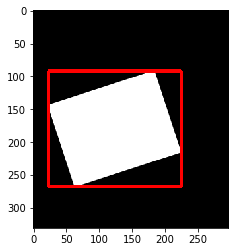

In [26]:
img = cv2.imread('box2.png')
im = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
ret,thresh = cv2.threshold(im,127,255,cv2.THRESH_BINARY)
contours, hierarchy = cv2.findContours(
    thresh,cv2.RETR_TREE,cv2.CHAIN_APPROX_SIMPLE)

x,y,w,h = cv2.boundingRect(contours[0])
print x,y,w,h
cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),3)

plt.imshow(img ,cmap = 'gray')
plt.show()

- **ثانيا- المستطيل المحدد المدور:**

وهنا يرسم المستطيل المحدد بمساحة اصغرية , وياخذ الدوران بالاعتبار
والتابع هو
<p dir='ltr'>
<strong> cv2.minAreaRect() </strong>
</p>
والذي يعطي زاوية الدوران بالاضافة للعرض والطول ,
وللرسم نحتاج الزوايا الاربع والتي يمكن اكتسابها وفق التابع ,
<p dir='ltr'>
<strong> cv2.boxPoints() </strong>
</p>

### الدائرة الاصغرية المحيطة:

<p style="text-align:center;font-size:1.4em;" dir='ltr'>
<strong> cv2.minEnclosingCircle() </strong>
</p>


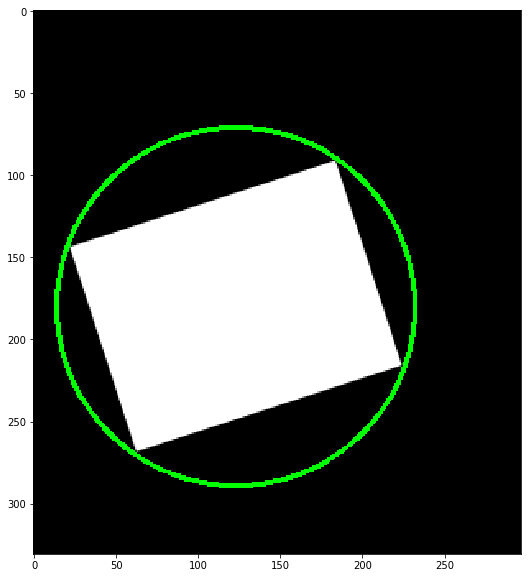

In [30]:
(x,y),radius = cv2.minEnclosingCircle(contours[0])
center = (int(x),int(y))
radius = int(radius)
img = cv2.imread('box2.png')
cv2.circle(img,center,radius,(0,255,0),2)

plt.figure(figsize=[10,10])
plt.imshow(img ,cmap = 'gray')
plt.show()

##  القطع الناقص المحيط:

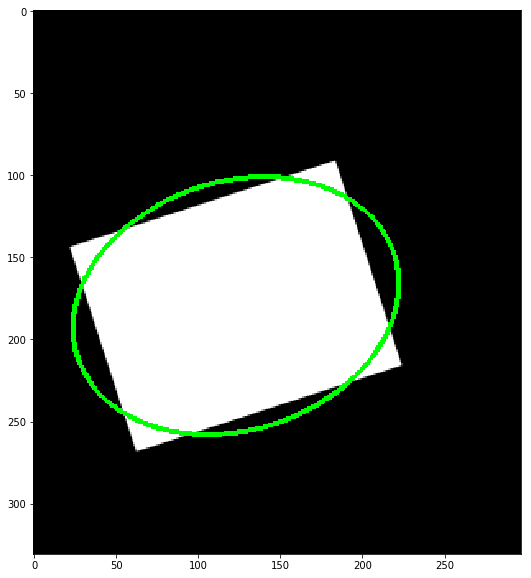

In [31]:
ellipse = cv2.fitEllipse(contours[0])
img = cv2.imread('box2.png')
cv2.ellipse(img,ellipse,(0,255,0),2)

plt.figure(figsize=[10,10])
plt.imshow(img ,cmap = 'gray')
plt.show()

### ملائمة خط
ايضا يمكننا رسم خط في الجسم المرغوب كالتالي
,حيث يتم الأمر بالتابع `fitLine`

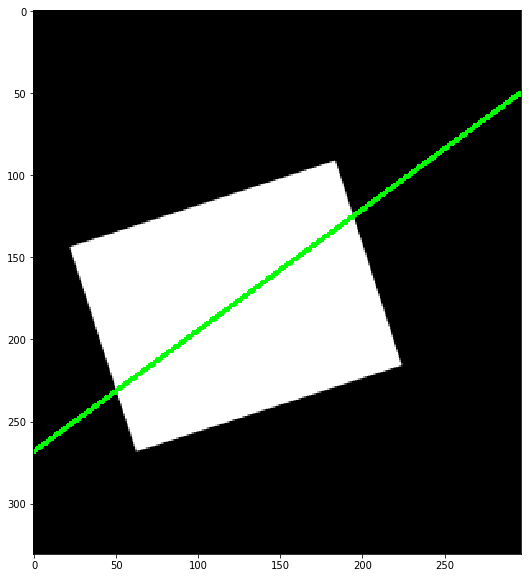

In [32]:
rows,cols = img.shape[:2]
[vx,vy,x,y] = cv2.fitLine(contours[0], cv2.DIST_LABEL_PIXEL,0,0.01,0.01)
lefty = int((-x*vy/vx) + y)
righty = int(((cols-x)*vy/vx)+y)

img = cv2.imread('box2.png')
cv2.line(img,(cols-1,righty),(0,lefty),(0,255,0),2)

plt.figure(figsize=[10,10])
plt.imshow(img ,cmap = 'gray')
plt.show()

كما ترون فالخط يلائم شكل المستقيم
## مراجع وتمارين..

